<a href="https://colab.research.google.com/github/Luyao-Xu/3-Class-Speech-Command-Classification/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 DataSet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

base_path = '/content/drive/MyDrive/speech_commands_project'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import os

data_dir = os.path.join(base_path, 'data')

os.makedirs(base_path, exist_ok=True)
print("Base path:", base_path)


data_path = tf.keras.utils.get_file(
    fname='speech_commands_v0.02.tar.gz',
    origin='http://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz',
    extract=True
)

print("Downloaded file:", data_path)

Base path: /content/drive/MyDrive/speech_commands_project
Downloaded file: /root/.keras/datasets/speech_commands_v0_extracted


In [ ]:
import os

base_path = '/content/drive/MyDrive/speech_commands_project'

folders = [
    'data/raw',
    'data/processed',
    'data/splits',
    'notebooks',
    'results/confusion_matrix',
    'results/plots',
    'results/tables'
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folder structure created in Google Drive.")

Folder structure created in Google Drive.


In [ ]:
import shutil

temp_extracted_path = '/root/.keras/datasets/speech_commands_v0_extracted'
permanent_raw_path = '/content/drive/MyDrive/speech_commands_project/data/raw'

classes = ["tree", "three", "two"]

for c in classes:
    src = os.path.join(temp_extracted_path, c)
    dst = os.path.join(permanent_raw_path, c)

    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"Moved {c} to Drive.")

Moved tree to Drive.
Moved three to Drive.
Moved two to Drive.


In [ ]:
import os
data_path = '/content/drive/MyDrive/speech_commands_project/data/raw'
classes = ["tree", "three", "two"]

for c in classes:
    folder = os.path.join(data_path, c)
    if os.path.exists(folder):

        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        print(f"Class '{c}': Found {len(files)} files.")
    else:
        print(f"Folder NOT found for class: {c}")

Class 'tree': Found 1759 files.
Class 'three': Found 3727 files.
Class 'two': Found 3880 files.


### Split data
To'splits' folder: train 80%/val 10%/test 10%

Reproducibility: I use a fixed random seed (42) to ensure the test set never leaks into the training set.

In [ ]:
import os
import random

data_path = '/content/drive/MyDrive/speech_commands_project/data/raw'
split_path = '/content/drive/MyDrive/speech_commands_project/data/splits'
classes = ["tree", "three", "two"]

random.seed(42)

train_list, val_list, test_list = [], [], []

for c in classes:
    folder = os.path.join(data_path, c)
    files = [os.path.join(c, f) for f in os.listdir(folder) if f.endswith('.wav')]

    random.shuffle(files)

    n = len(files)
    train_idx = int(n * 0.8)
    val_idx = int(n * 0.9)

    train_list.extend(files[:train_idx])
    val_list.extend(files[train_idx:val_idx])
    test_list.extend(files[val_idx:])

for name, l in zip(['train.txt', 'val.txt', 'test.txt'], [train_list, val_list, test_list]):
    with open(os.path.join(split_path, name), 'w') as f:
        f.write('\n'.join(l))

print(f" Split complete: {len(train_list)} train, {len(val_list)} val, {len(test_list)} test files recorded.")

 Split complete: 7492 train, 937 val, 937 test files recorded.


# 2 The Preprocessing & Augmentation Script

N_MFCC = 40   # Number of MFCC coefficients

In [ ]:
import os
import librosa
import numpy as np
import random

BASE_PATH = '/content/drive/MyDrive/speech_commands_project'
DATA_PATH = os.path.join(BASE_PATH, 'data/raw')
SPLIT_PATH = os.path.join(BASE_PATH, 'data/splits')
PROCESSED_PATH = os.path.join(BASE_PATH, 'data/processed')

SAMPLE_RATE = 16000
DURATION = 1
N_MFCC = 40

def extract_features(file_path, augment=False):
    # 1. Load audio
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # 2. Ensure 1s duration (Padding/Clipping)
    if len(audio) < SAMPLE_RATE:
        audio = np.pad(audio, (0, SAMPLE_RATE - len(audio)), 'constant')
    else:
        audio = audio[:SAMPLE_RATE]

    # 3. Data Augmentation (Only for Training set)
    if augment:
        # Time Shifting
        shift = int(random.uniform(-1600, 1600)) # up to 100ms
        audio = np.roll(audio, shift)

        # Add Background Noise
        noise_amp = 0.005 * np.random.uniform() * np.amax(audio)
        audio = audio + noise_amp * np.random.normal(size=audio.shape)

        # Volume Scaling
        audio = audio * random.uniform(0.8, 1.2)

    # 4. Normalize Audio
    audio = librosa.util.normalize(audio)

    # 5. Extract MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    return mfcc

def process_split(split_name):
    print(f"Processing {split_name}...")
    X, y = [], []
    label_map = {'tree': 0, 'three': 1, 'two': 2}

    # Load the list of files for this split
    with open(os.path.join(SPLIT_PATH, f'{split_name}.txt'), 'r') as f:
        file_list = f.read().splitlines()

    for file_rel_path in file_list:
        full_path = os.path.join(DATA_PATH, file_rel_path)
        label_str = file_rel_path.split('/')[0]

        # Augment only the training set
        is_train = (split_name == 'train')
        features = extract_features(full_path, augment=is_train)

        X.append(features)
        y.append(label_map[label_str])

    # Save as numpy files for future traceability
    np.save(os.path.join(PROCESSED_PATH, f'X_{split_name}.npy'), np.array(X))
    np.save(os.path.join(PROCESSED_PATH, f'y_{split_name}.npy'), np.array(y))
    print(f"Saved {split_name} features to Drive.")

# Execute for all splits
os.makedirs(PROCESSED_PATH, exist_ok=True)
for split in ['train', 'val', 'test']:
    process_split(split)

Processing train...
Saved train features to Drive.
Processing val...
Saved val features to Drive.
Processing test...
Saved test features to Drive.


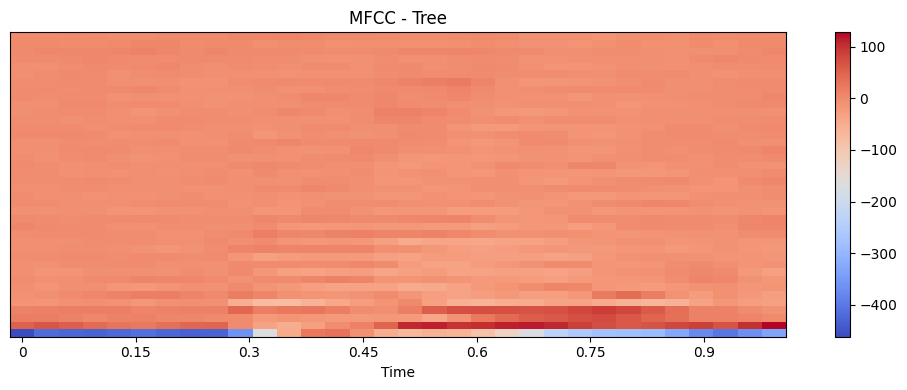

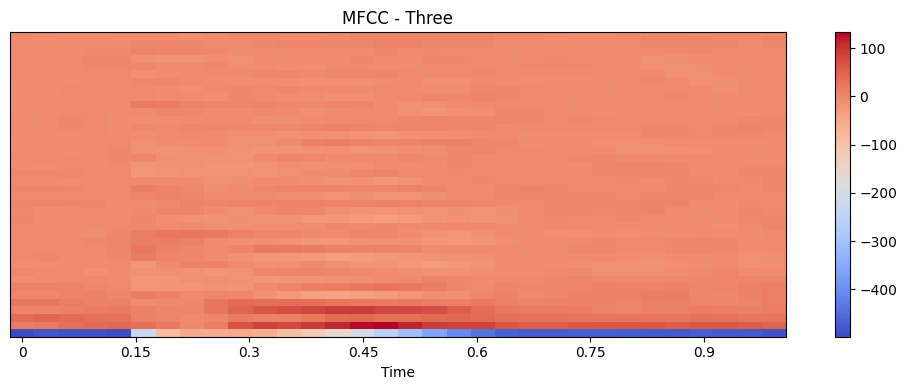

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

def plot_mfcc(file_path, title):
    # Extract features using your function
    mfcc = extract_features(file_path, augment=False)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=SAMPLE_RATE)
    plt.colorbar()
    plt.title(f'MFCC - {title}')
    plt.tight_layout()
    plt.show()

# Pick one 'tree' and one 'three' file from your Drive to compare
plot_mfcc(os.path.join(DATA_PATH, 'tree/ffb86d3c_nohash_0.wav'), 'Tree')
plot_mfcc(os.path.join(DATA_PATH, 'three/ffd2ba2f_nohash_3.wav'), 'Three')

In [ ]:
from IPython.display import Audio

def listen_to_processed(file_path, augment=True):
    # We need the raw audio before MFCC conversion to hear it
    audio, _ = librosa.load(file_path, sr=SAMPLE_RATE)

    # Apply your padding and augmentation logic
    if len(audio) < SAMPLE_RATE:
        audio = np.pad(audio, (0, SAMPLE_RATE - len(audio)), 'constant')

    # Display the player
    return Audio(audio, rate=SAMPLE_RATE)

# Try listening to a 'three' sample
listen_to_processed(os.path.join(DATA_PATH, 'three/ff63ab0b_nohash_0.wav'))